# Figures & Tables Generation Notebook

Running this notebook enables you to regenerate the figures and tables of the original paper. 

In [ ]:
# Importing essential libraries

import pandas as pd
import random

# Seed for random states
seed= 42
rng = random.Random(seed)


from sklearn.metrics import accuracy_score

import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import numpy as np

import re
from matplotlib.colors import LinearSegmentedColormap

In [2]:
# Load test set
benchmark_name= "politicaltr"


# Load test set
# benchmark_name= "tram"

index2option= {0:"A)", 1:"B)", 2:"C)"}
option2index= {"A)":0, "B)":1, "C)":2}

tr_all_tasks= ["Ordering", "Typical Time", "Temporal NLI", "Storytelling"]

task_types= [   "0s_question", "1s_question", "3s_question",
            ]

pretrained_model_names= [
                        'gpt2-large', 
                        'gemma-3-1b-pt', 
                        'Llama-3.2-1B', 
                        'DeepSeek-R1-Distill-Qwen-1.5B', 
                        'Qwen3-1.7B',
                            ]


discourse_over_period= {
    "Ordering":["Q1", "Q2"],
    "Typical Time":["Q1"],
    "Temporal NLI":["Q1", "Q2", "Q3"],
    "Storytelling":[],
}

period_over_discourse= {
    "Ordering":["Q3", "Q4"],
    "Typical Time":["Q2"],
    "Temporal NLI":[],
    "Storytelling":["Q1", "Q2", "Q3"],
}

preceded= {
    "Ordering":["Q1", "Q3"],
    "Typical Time":[],
    "Temporal NLI":["Q2"],
    "Storytelling":["Q2"],
}

current= {
    "Ordering":[],
    "Typical Time":["Q1", "Q2"],
    "Temporal NLI":["Q1"],
    "Storytelling":["Q1"],
}

followed= {
    "Ordering":["Q2", "Q4"],
    "Typical Time":[],
    "Temporal NLI":["Q3"],
    "Storytelling":["Q3"],
}

task_labels = {
            "0s_question": "0-shot",
            "1s_question": "1-shot",
            "3s_question": "3-shot",
            "entail": "Entail",
            "not_entail": "Not entail",
            "preceded": "Preceded", 
            "current": "Current", 
            "followed": "Followed",
            "period_over_discourse": "Period→Discourse",
            "discourse_over_period": "Discourse→Period"
        }

task_colors = {
    # Blue (0-shot)
    "0s_question":       "#CFE8FF",  # bright
    "0s_cot_question":   "#1F77B4",  # dark

    # orange (1-shot)
    "1s_question":       "#FFE0C2",  # bright
    "1s_cot_question":   "#FF7F0E",  # dark

    # Green (3-shot)
    "3s_question":       "#DDF2D9",  # bright
    "3s_cot_question":   "#2CA02C",  # dark
}


def get_stats(benchmark):
    stats= {}
    results= {}
    
    for pretrained_model_name in pretrained_model_names:
        stats[pretrained_model_name]= {}

    result_path= "/home/ibai/OEG/eswc2026/data/tr_benchmarks/{benchmark}/results/{model}.csv"

    for pretrained_model_name in pretrained_model_names:
        
        test= pd.read_csv(result_path.format(benchmark=benchmark, model=pretrained_model_name))
        test["test_id_base"] = test["test_id"].str.replace(r'_(T|F)$', '', regex=True)

        results[pretrained_model_name]= test
        stats[pretrained_model_name]["General"]= {}

        for task_type in task_types:
                
            gold_label= test["gold_label"]
            target_label = (
                test[f"target_{task_type}"]
                .map(option2index)   # Convierte A/B/C a sus índices
                .fillna(-1)          # Todo lo que no esté en option2index se marca como -1
                .astype(int)         # Asegura tipo entero
            )
            
            #general_acc= accuracy_score(gold_label, target_label)
            
            invalid_test= test[~test[f"target_{task_type}"].isin(option2index.keys())]
            coverage= round((len(test)- len(invalid_test)) / len(test), 3)
            
            # print("###"*10)
            # print(f"Task: {task_type}")
            # print(f"Coverage: {coverage}")
            # print(f"Accuracy: {general_acc}")
            # print(f"Number of VALID responses: {len(test[test[f'target_{task_type}'].isin(option2index.keys())])}")
            # print(f"Number of invalid responses: {len(invalid_test)}")

            # Paso 1.2: Agregar a la informacion
            test[f"target_label_{task_type}"] = target_label #valid_test[f"target_{task_type}"].map(option2index)

            accuracy_by_task = (
                test
                .groupby("task")
                .agg(
                    accuracy=("gold_label", lambda x: accuracy_score(x, test.loc[x.index, f"target_label_{task_type}"])),
                    count=("gold_label", "count")
                )
                .reset_index()
                .sort_values(by="accuracy", ascending=False)
            )
            general_acc= accuracy_by_task["accuracy"].mean()
            accuracy_by_taskid = (
                test
                .groupby(["task", "test_id"])
                .agg(
                    accuracy=("gold_label", lambda x: accuracy_score(x, test.loc[x.index, f"target_label_{task_type}"])),
                    count=("gold_label", "count")
                )
                .reset_index()
                .sort_values(by="accuracy", ascending=False)
            )

            accuracy_by_taskid_grouped = (
                test
                .groupby(["task", "test_id_base"])
                .agg(
                    accuracy=("gold_label", lambda x: accuracy_score(x, test.loc[x.index, f"target_label_{task_type}"])),
                    count=("gold_label", "count")
                )
                .reset_index()
                .sort_values(by="accuracy", ascending=False)
            )

            task_results= (
                accuracy_by_taskid_grouped.groupby('task', sort=False)
                .apply(lambda g: dict(zip(g['test_id_base'], g['accuracy'].round(3))))
                .to_dict()
            )
            for tr_task in tr_all_tasks:
                task_results[tr_task]["overall"]= accuracy_by_task[accuracy_by_task["task"]==tr_task]["accuracy"].iloc[0].round(3)
                task_results[tr_task]["count"]= int(accuracy_by_task[accuracy_by_task["task"]==tr_task]["count"].iloc[0])
                
            stats[pretrained_model_name]["General"][task_type]= {
                "coverage": coverage,
                "overall": round(general_acc, 3),
                "specific": task_results
            }
    for pretrained_model_name in pretrained_model_names:

        stats[pretrained_model_name]["Temporal NLI"]= {}
        stats[pretrained_model_name]["Timeline"]= {}
        stats[pretrained_model_name]["Subject"]= {}

        # NLI Entail vs Not Entail stats
        # nli_entail= nli_results[nli_results["test_id"].str.contains("_T")]
        # nli_not_entail= nli_results[nli_results["test_id"].str.contains("_F")]
        nli_results= results[pretrained_model_name][results[pretrained_model_name]["task"]=="Temporal NLI"]
        
        for task_type in task_types:
            nli_results["responses"]= nli_results[task_type].str.split("Choices:").str[-1].str.split("# The only").str[0].str.replace(r'[\n\r]', ' ', regex=True)

            if nli_results["responses"].str.contains(r'\bC\)', regex=True).any():
                opts= nli_results["responses"].str.extract(r'A\)\s*(.*?)\s+B\)\s*(.*)\s+C\)\s*(.*)$')
                opts.columns = ["A)", "B)", "C"]

                nli_results["expected"]= opts.to_numpy()[
                    range(len(opts)),
                    nli_results["answer"]
                        .str.extract(r'([ABC])', expand=False)  # extrae la letra
                        .map({'A': 0, 'B': 1, 'C': 2})          # mapea a índice numérico
                        .fillna(-1) 
                        .astype(int)
                ]
                nli_results["expected"]= nli_results["expected"].str.strip().replace({
                    "entailment": "entail",
                    "contradiction": "not entail"
                })
            else:
                opts= nli_results["responses"].str.extract(r'A\)\s*(.*?)\s+B\)\s*(.*)$')
                opts.columns = ["A)", "B)"]

                nli_results["expected"]= opts.to_numpy()[
                    range(len(opts)),
                    nli_results["answer"]
                        .str.extract(r'([AB])', expand=False)
                        .eq("B")
                        .fillna(-1)
                        .astype(int)
                ]
                nli_results["expected"]= nli_results["expected"].str.strip()
            
            nli_not_entail= nli_results[nli_results["expected"]=="not entail"]
            nli_entail= nli_results[nli_results["expected"]=="entail"]

            stats[pretrained_model_name]["Temporal NLI"][f"{task_type}"]= {
                                                                            "entail": accuracy_score(nli_entail["gold_label"], nli_entail[f"target_label_{task_type}"]),
                                                                            "not_entail": accuracy_score(nli_not_entail["gold_label"], nli_not_entail[f"target_label_{task_type}"])
                                                                            }
            

        # Preceding VS Current VS Following reasoning
        df_preceded= []
        df_current= []
        df_followed= []
        for _tr_task in tr_all_tasks:
            df_preceded.append(
                results[pretrained_model_name][
                    (results[pretrained_model_name]["task"]==_tr_task) &
                    (results[pretrained_model_name]["test_id"].isin(preceded[_tr_task]))
                ]
            )
            df_current.append(
                results[pretrained_model_name][
                    (results[pretrained_model_name]["task"]==_tr_task) &
                    (results[pretrained_model_name]["test_id"].isin(current[_tr_task]))
                ]
            )
            df_followed.append(
                results[pretrained_model_name][
                    (results[pretrained_model_name]["task"]==_tr_task) &
                    (results[pretrained_model_name]["test_id"].isin(followed[_tr_task]))
                ]
            )

        df_preceded= pd.concat(df_preceded)
        df_current=  pd.concat(df_current)
        df_followed= pd.concat(df_followed)

        for task_type in task_types:
            stats[pretrained_model_name]["Timeline"][f"{task_type}"]= {
                "preceded": accuracy_score(df_preceded["gold_label"], df_preceded[f"target_label_{task_type}"]),
                "current":  accuracy_score(df_current["gold_label"],  df_current[f"target_label_{task_type}"]),
                "followed": accuracy_score(df_followed["gold_label"], df_followed[f"target_label_{task_type}"])
            }

        # Period over Discourse and Discourse over Period reasoning
        df_discurse_over_period= []
        df_period_over_discourse= []
        for _tr_task in tr_all_tasks:
            df_discurse_over_period.append(
                results[pretrained_model_name][
                    (results[pretrained_model_name]["task"]==_tr_task) &
                    (results[pretrained_model_name]["test_id"].isin(discourse_over_period[_tr_task]))
                ]
            )

            df_period_over_discourse.append(
                results[pretrained_model_name][
                    (results[pretrained_model_name]["task"]==_tr_task) &
                    (results[pretrained_model_name]["test_id"].isin(period_over_discourse[_tr_task]))
                ]
            )

        df_discurse_over_period=   pd.concat(df_discurse_over_period)
        df_period_over_discourse=  pd.concat(df_period_over_discourse)

        for task_type in task_types:
            stats[pretrained_model_name]["Subject"][f"{task_type}"]= {
                "discourse_over_period": accuracy_score(df_discurse_over_period["gold_label"], df_discurse_over_period[f"target_label_{task_type}"]),
                "period_over_discourse":  accuracy_score(df_period_over_discourse["gold_label"],  df_period_over_discourse[f"target_label_{task_type}"])
            }
    return stats


def generate_summary_table(stats):
    rows = []
    row_index = []  # (Model, Configuration)

    def _cfg_label(k: str) -> str:
        m = re.fullmatch(r'(\d+)s(?:_(cot))?_question', k)
        if not m:
            return k
        num, cot = m.group(1), m.group(2)
        return f"{num}-shot" + ("-CoT" if cot else "")

    # 1) Discover the tasks and question keys
    all_tasks = set()
    qkeys_per_task = {}

    for model, model_dict in stats.items():
        gen_dict = model_dict.get("General", {})
        if not gen_dict:
            continue
        gen_name, gen_vals = next(iter(gen_dict.items()))  
        specific = gen_vals.get("specific", {})
        for task, qmap in specific.items():
            all_tasks.add(task)
            qkeys_per_task.setdefault(task, set())
            for k in qmap.keys():
                qkeys_per_task[task].add(k)

    # Orden of questions Q*
    q_order = ["Q1","Q2","Q3","Q4","overall"]

    # 2) Build the columns
    col_tuples = []
    for task in sorted(all_tasks):
        qs = [q for q in q_order if q in qkeys_per_task.get(task, set())]
        for q in qs:
            col_tuples.append(("Specific", task, q))

    # Add last General columns: overall and coverage
    col_tuples.append(("General", "", "overall"))
    col_tuples.append(("General", "", "coverage"))

    columns = pd.MultiIndex.from_tuples(col_tuples)


    for model, model_dict in stats.items():
        gen_dict = model_dict.get("General", {})
        if not gen_dict:
            continue
        for gen_key, gen_vals in gen_dict.items():
            cfg = _cfg_label(gen_key)  # 0s_question -> 0_shot, etc.
            specific = gen_vals.get("specific", {}) or {}
            overall_general = gen_vals.get("overall", np.nan)
            coverage_general = gen_vals.get("coverage", np.nan)

            row = {}
            # Specific
            for task in sorted(tr_all_tasks):
                qmap = specific.get(task, {}) or {}
                for q in q_order:
                    tup = ("Specific", task, q)
                    if tup in columns:
                        row[tup] = qmap.get(q, np.nan)
            # General
            row[("General", "", "overall")]  = overall_general
            row[("General", "", "coverage")] = coverage_general

            rows.append(row)
            row_index.append((model, cfg))

    # DataFrame with multilevel index
    df = pd.DataFrame(rows, index=pd.MultiIndex.from_tuples(row_index, names=["Model","Configuration"]),
                    columns=columns).round(3)
    # df = df.sort_index()

    config_order= ["0-shot", "0-shot-CoT", "1-shot", "1-shot-CoT", "3-shot", "3-shot-CoT"]

    # 1) Order indexes
    model_idx = pd.CategoricalIndex(
        df.index.get_level_values("Model"),    # usa el nombre del nivel
        categories=pretrained_model_names,
        ordered=True,
        name="Model",
    )
    config_idx = pd.CategoricalIndex(
        df.index.get_level_values("Configuration"),
        categories=config_order,
        ordered=True,
        name="Configuration",
    )

    # 2) Order
    df.index = pd.MultiIndex.from_arrays([model_idx, config_idx], names=["Model", "Configuration"])
    df = df.sort_index(level=["Model", "Configuration"])

    df= df.apply(
        lambda col: col * 100 if pd.api.types.is_numeric_dtype(col) else col
    )


    # Colors
    cmap = LinearSegmentedColormap.from_list(
        "red_yellow_green",
        ["#d73027", "#fdae61", "#ffffbf", "#a6d96a", "#1a9850"]
    )

    num_cols = df.select_dtypes(include="number").columns

    styled = (
        df.style
        .format(precision=1)
        .background_gradient(cmap=cmap, vmin=0, vmax=100, axis=None,
                                subset=pd.IndexSlice[:, num_cols])
    )

    return df, styled


def generate_multiway_plot(results_dict,
                           benchmark_name="Temporal NLI",
                           task_order=None,
                           task_labels=None,      # dict {task_type: pretty_name}
                           task_colors=None,      # dict {task_type: color}  (opcional)
                           labels=("entail","not_entail"),  # categorías variables
                           label_hatches=None,    # dict {label: hatch}; None -> defaults
                           figsize=(17, 6),
                           savepath=None,
                           show_separators=True,
                           separator_color="0.0",
                           separator_linestyle="--",
                           separator_linewidth=1.0,
                           separator_alpha=0.9,
                           title="Model Performance by Experiment & Category",
                           ylabel="Accuracy",
                           show_value_labels=True,
                           value_fmt="{:.0f}",
                           value_fontsize=18,
                           value_offset=0.0  # desplazamiento vertical
                           
                           ):
    """
    Single chart with:
      - X-axis: models
      - For each model: groups by experiment (task_type), each with len(labels) bars.
      - Color encodes experiment; hatch encodes category.
      - Combined legend: experiments (color) + categories (style).
      - Y-axis fixed to [0, 1].
    Works with any number of categories in `labels`.
    """

    models = list(results_dict.keys())
    if not models:
        raise ValueError("results_dict is empty.")

    # Infer task order from first model if not provided
    if task_order is None:
        first_model = models[0]
        bench = results_dict[first_model].get(benchmark_name, {})
        task_order = list(bench.keys())

    # Default pretty labels for experiments
    if task_labels is None:
        task_labels = {
            "0s_question": "0-shot",
            "1s_question": "1-shot",
            "3s_question": "3-shot",
            "0s_cot_question": "0-shot CoT",
            "1s_cot_question": "1-shot CoT",
            "3s_cot_question": "3-shot CoT",
            "entail": "Entail",
            "not_entail": "Not entail",
            "preceded": "Preceded", 
            "current": "Current", 
            "followed": "Followed",
            "period_over_discourse": "Period→Discourse",
            "discourse_over_period": "Discourse→Period"
        }

    # Default hatches per category
    if label_hatches is None:
        # Choose sensible defaults for common cases
        defaults = {
            "entail": None, 
            "not_entail": "\\\\", 
            "preceded": "//", 
            "current": None, 
            "followed": "\\\\",
            "period_over_discourse": None,
            "discourse_over_period": "\\\\"
        }
        label_hatches = {lab: defaults.get(lab, None) for lab in labels}
    else:
        # ensure all labels exist
        for lab in labels:
            label_hatches.setdefault(lab, None)

    # Collect scores[(model, task, label)]
    scores = {}
    for model in models:
        bench = results_dict.get(model, {}).get(benchmark_name, {})
        for task in task_order:
            vals = bench.get(task, {})
            for lab in labels:
                scores[(model, task, lab)] = vals.get(lab, 0.0)

    n_models = len(models)
    n_tasks  = len(task_order)
    n_labels = len(labels)
    x = np.arange(n_models)

    # ---- Layout (no overlap), general for any n_labels ----
    group_span     = 0.9          # total width per model group
    label_gap_mult = 0.30         # gap between bars inside an experiment (in bar widths)
    exp_gap_mult   = 0.60         # gap between experiments inside a model group (in bar widths)

    denom    = (n_tasks * (n_labels + (n_labels - 1) * label_gap_mult)
                + (n_tasks - 1) * exp_gap_mult)
    bar_w     = group_span / denom
    label_gap = label_gap_mult * bar_w
    exp_gap   = exp_gap_mult * bar_w

    exp_block_width   = n_labels * bar_w + (n_labels - 1) * label_gap
    model_group_width = n_tasks * exp_block_width + (n_tasks - 1) * exp_gap

    exp_offsets = []
    current = -model_group_width / 2
    for _ in range(n_tasks):
        exp_offsets.append(current)
        current += exp_block_width + exp_gap

    fig, ax = plt.subplots(figsize=figsize)

    # Track actual colors used per experiment to build a reliable legend,
    # even if task_colors is None (fallback to first drawn bar color).
    used_task_colors = {}

    # Draw bars
    for m_idx, model in enumerate(models):
        group_center = x[m_idx]
        for t_idx, task in enumerate(task_order):
            left  = group_center + exp_offsets[t_idx]
            color = None if task_colors is None else task_colors.get(task, None)

            for i, lab in enumerate(labels):
                xpos   = left + i * (bar_w + label_gap)
                height = scores.get((model, task, lab), 0.0)
                style  = dict(width=bar_w, color=color, edgecolor="black", linewidth=0.5)
                hatch  = label_hatches.get(lab, None)
                if hatch:
                    style["hatch"] = hatch
                bars = ax.bar(xpos, height, **style)

                # Save the actual facecolor used for this experiment if not provided
                if task not in used_task_colors:
                    used_task_colors[task] = bars[0].get_facecolor()

                if show_value_labels:
                    # Coloca el texto un poco por encima, pero sin salir de [0,1]
                    y_text = min(height + value_offset, 0.985)
                    txt = value_fmt.format(height * 100.0)  # float -> porcentaje
                    ax.text(xpos, y_text, txt,
                            ha="center", va="bottom",
                            fontsize=value_fontsize)

    # Axes
    ax.set_xticks(x)
    ax.set_xticklabels(models, fontsize=18, rotation=0, ha="center")
    ax.set_ylim(0, 1.0)
    ax.set_ylabel(ylabel, fontsize=18)
    # ax.set_title(title, fontsize=18)
    ax.margins(x=0.01, y=0.02)
    # Optional vertical separators between model groups
    if show_separators and n_models > 1:
        for i in range(n_models - 1):
            ax.vlines(i + 0.48, 0.0, 1.0,
                      colors=separator_color,
                      linestyles=separator_linestyle,
                      linewidth=separator_linewidth,
                      alpha=separator_alpha,
                      zorder=0)

    # ---- Single combined legend ----
    # Experiment proxies (one per task_type, using the actual colors we used)
    exp_handles, exp_labels = [], []
    for task in task_order:
        if task in used_task_colors:
            exp_handles.append(Patch(facecolor=used_task_colors[task], edgecolor="black"))
            exp_labels.append(task_labels.get(task, task))

    # Category proxies (style only, neutral color)
    style_handles, style_labels = [], []
    for lab in labels:
        style_handles.append(Patch(facecolor="0.8", edgecolor="black",
                                   hatch=(label_hatches[lab] or "")))
        style_labels.append(task_labels.get(lab, lab))

    handles = exp_handles + style_handles
    labels_ = exp_labels + style_labels

    ax.legend(handles, labels_,
              title="Experiment (color) & Category (style)",
              loc="upper left", 
              frameon=True, framealpha=0.9,
              borderpad=0.3, labelspacing=0.4, handlelength=1.2,
              ncol=min(3, round(len(labels_)/3)), 
              fontsize=16,          
              title_fontsize=16     
              )

    plt.tight_layout()

    if savepath:
        fig.savefig(savepath, dpi=300, bbox_inches="tight")
        print(f"Figure saved at {savepath}")
    return fig, ax

def combine_benchmark_tables(benchmark1, benchmark2):       
    # --- 0) Ensure index (Model, Configuration) without resetting it if it is already set ---
    def ensure_mc_index(df):
        if isinstance(df.index, pd.MultiIndex) and df.index.nlevels == 2:
            # Name it if it doesn't have names
            names = list(df.index.names)
            if names != ["Model", "Configuration"]:
                df.index = df.index.set_names(["Model", "Configuration"])
            return df
        # If it comes without an index, as a fallback use columns
        if {"Model", "Configuration"}.issubset(df.columns):
            return df.set_index(["Model", "Configuration"])
        raise ValueError("Cannot find index (Model, Configuration) or columns to construct it.")

    benchmark1 = ensure_mc_index(benchmark1.copy())
    benchmark2   = ensure_mc_index(benchmark2.copy())

    # --- 1) Existing tasks ---
    tasks = sorted({c[1] for c in benchmark1.columns if len(c) == 3 and c[0] == "Specific"})

    # --- 2) Build base output ---
    df_out = benchmark1.copy()

    # --- 3) Add TRAM after the overall of each task ---
    for t in tasks:
        src = ("Specific", t, "overall")
        dst = ("Specific", t, "TRAM")
        df_out[dst] = benchmark2[src] if src in benchmark2.columns else np.nan

    # --- 4) General: overall/coverage PoliTR y TRAM ---
    gen_overall  = ("General", "", "overall")
    gen_coverage = ("General", "", "coverage")

    # PoliTR 
    if gen_overall in df_out.columns:
        df_out[("General", "overall_PoliTR", "")] = df_out[gen_overall]
        df_out = df_out.drop(columns=[gen_overall])
    if gen_coverage in df_out.columns:
        df_out[("General", "coverage_PoliTR", "")] = df_out[gen_coverage]
        df_out = df_out.drop(columns=[gen_coverage])

    # TRAM
    if gen_overall in benchmark2.columns:
        df_out[("General", "overall_TRAM", "")] = benchmark2[gen_overall]
    if gen_coverage in benchmark2.columns:
        df_out[("General", "coverage_TRAM", "")] = benchmark2[gen_coverage]

    # --- 5) Reorder: TRAM after each overall of each task ---
    cols = list(df_out.columns)
    new_cols = []
    for t in tasks:
        t_cols = [c for c in cols if c[0] == "Specific" and c[1] == t]
        seen = set()
        for c in t_cols:
            if c not in seen:
                new_cols.append(c); seen.add(c)
            if c == ("Specific", t, "overall"):
                tram_c = ("Specific", t, "TRAM")
                if tram_c in cols and tram_c not in seen:
                    new_cols.append(tram_c); seen.add(tram_c)

    # General in order
    general_order = [
        ("General", "overall_PoliTR", ""),
        ("General", "overall_TRAM", ""),
        ("General", "coverage_PoliTR", ""),
        ("General", "coverage_TRAM", ""),
    ]
    new_cols += [c for c in general_order if c in df_out.columns]

    # Rest
    new_cols += [c for c in cols if c not in new_cols]

    # Order
    df_out = df_out.reindex(columns=pd.MultiIndex.from_tuples(new_cols, names=df_out.columns.names))

    # Colors
    cmap = LinearSegmentedColormap.from_list(
        "red_yellow_green",
        ["#d73027", "#fdae61", "#ffffbf", "#a6d96a", "#1a9850"]
    )

    num_cols = df_out.select_dtypes(include="number").columns

    styled = (
        df_out.style
        .format(precision=1)
        .background_gradient(cmap=cmap, vmin=0, vmax=100, axis=None,
                                subset=pd.IndexSlice[:, num_cols])
    )


    # Final result
    return df_out, styled

In [3]:
benchmarks= ["politicaltr", "TRAM"]

politicaltr_stats= get_stats("politicaltr")
tram_stats= get_stats("TRAM")

/tmp/ipykernel_31509/61440708.py:165: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: dict(zip(g['test_id_base'], g['accuracy'].round(3))))
/tmp/ipykernel_31509/61440708.py:165: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: dict(zip(g['test_id_base'], g['accuracy'].round(3))))
/tmp/ipykernel_31509/61440708.py:165: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. 

In [4]:
tram= generate_summary_table(tram_stats)
tram[1].to_excel("tram_summary_table.xlsx", engine='openpyxl')

politr= generate_summary_table(politicaltr_stats)
politr[1].to_excel("politicaltr_summary_table.xlsx", engine='openpyxl')

combined= combine_benchmark_tables(politr[0], tram[0])
combined[1].to_excel("combined_politicaltr_tram_summary_table.xlsx", engine='openpyxl')
combined[1]

Figure saved at time.svg
Figure saved at nli_bias.svg
Figure saved at subject.svg


(<Figure size 1700x600 with 1 Axes>, <Axes: ylabel='Accuracy'>)

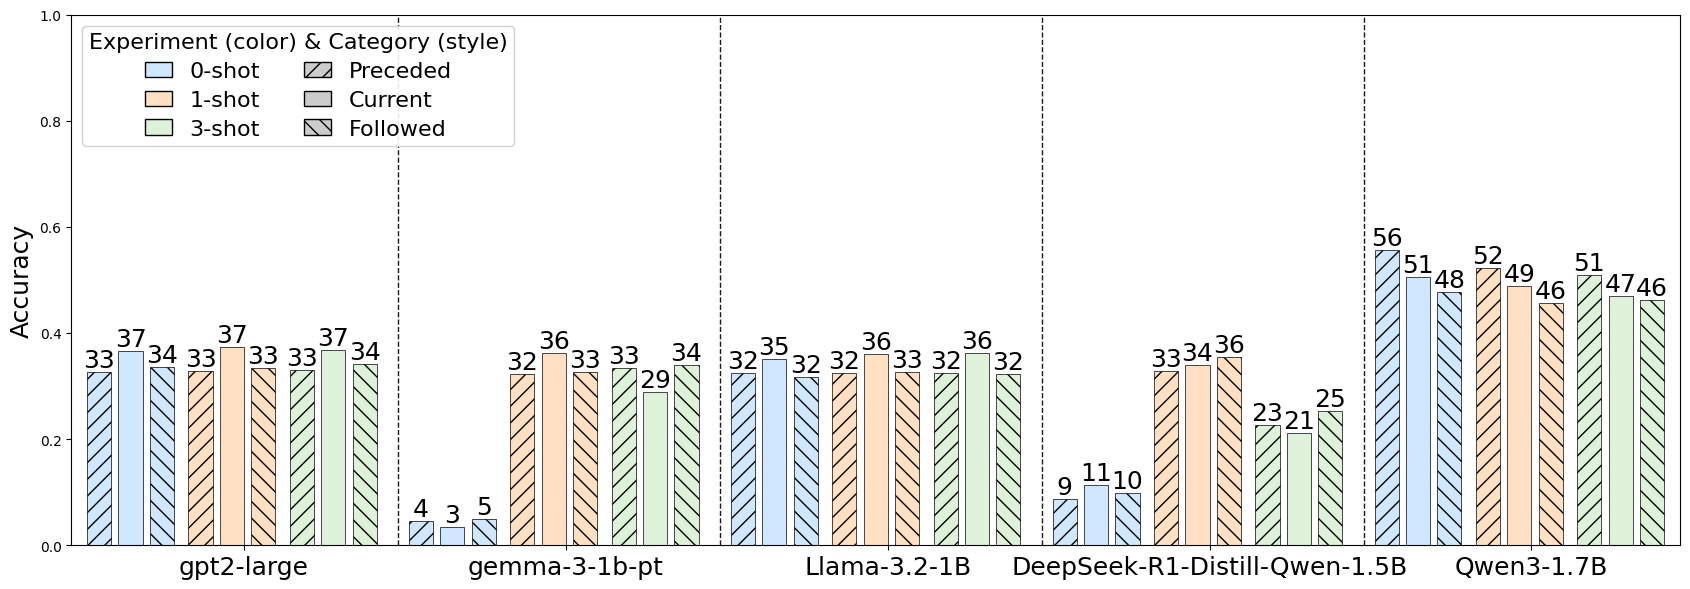

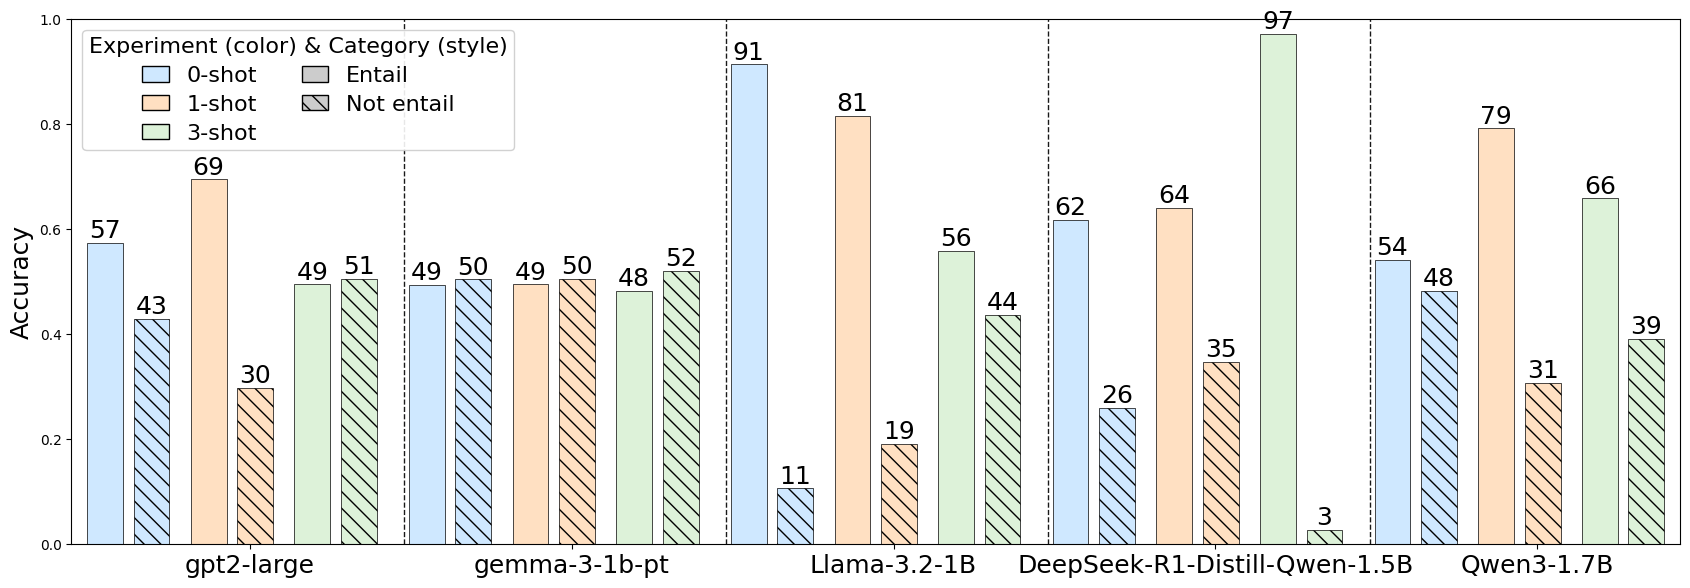

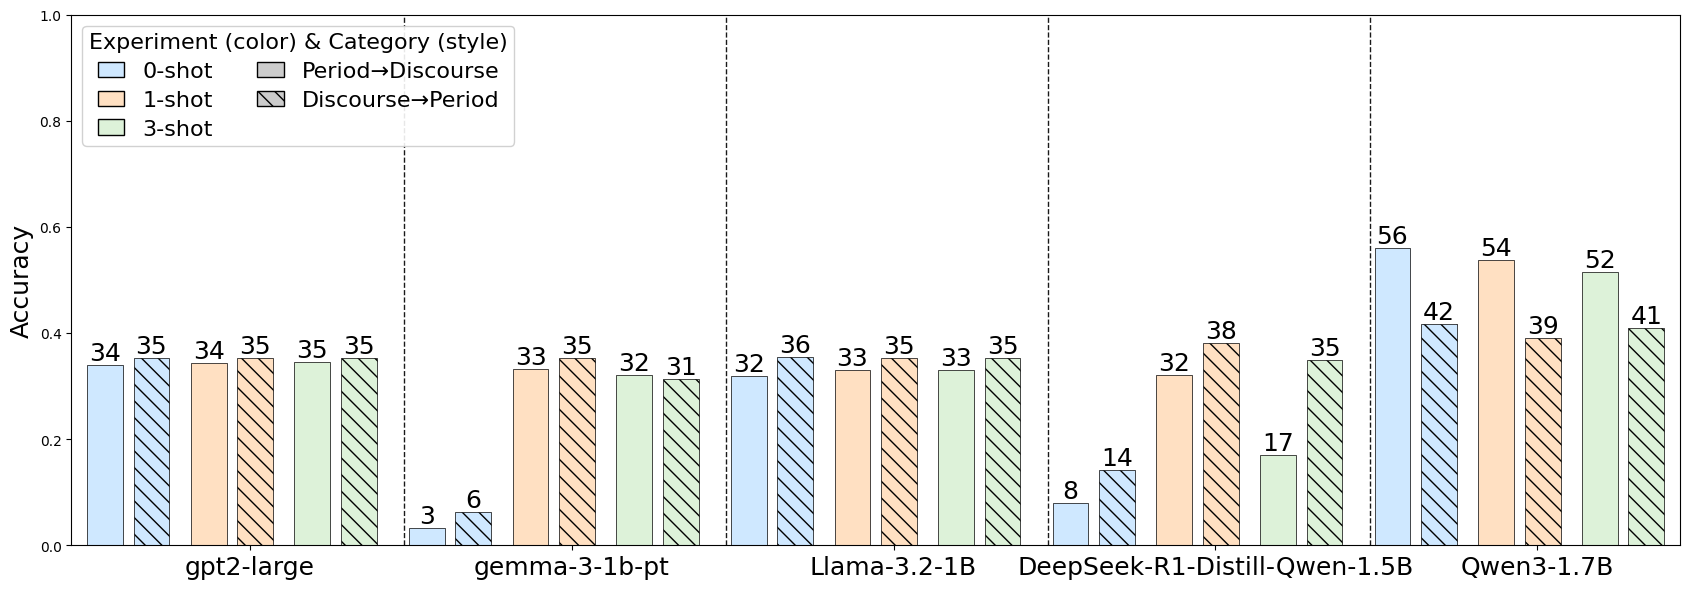

In [5]:


generate_multiway_plot(politicaltr_stats, title="Model Performance to Resolve Preceded, Current, and Followed Relations", benchmark_name= "Timeline", labels=("preceded", "current", "followed"), savepath= "time.svg", task_colors=task_colors, task_labels=task_labels)
generate_multiway_plot(politicaltr_stats, title="Model Performance for Temporal NLI in Entail and Not Entail Responses", benchmark_name="Temporal NLI", labels=("entail", "not_entail"), savepath= "nli_bias.svg",task_colors=task_colors, task_labels=task_labels)
generate_multiway_plot(politicaltr_stats, title="Performance on Discourse→Period and Period→Discourse Reasoning", benchmark_name="Subject", labels=("period_over_discourse", "discourse_over_period"), savepath= "subject.svg", task_colors=task_colors, task_labels=task_labels)


Figure saved at nli_bias_tram.svg


(<Figure size 1700x600 with 1 Axes>, <Axes: ylabel='Accuracy'>)

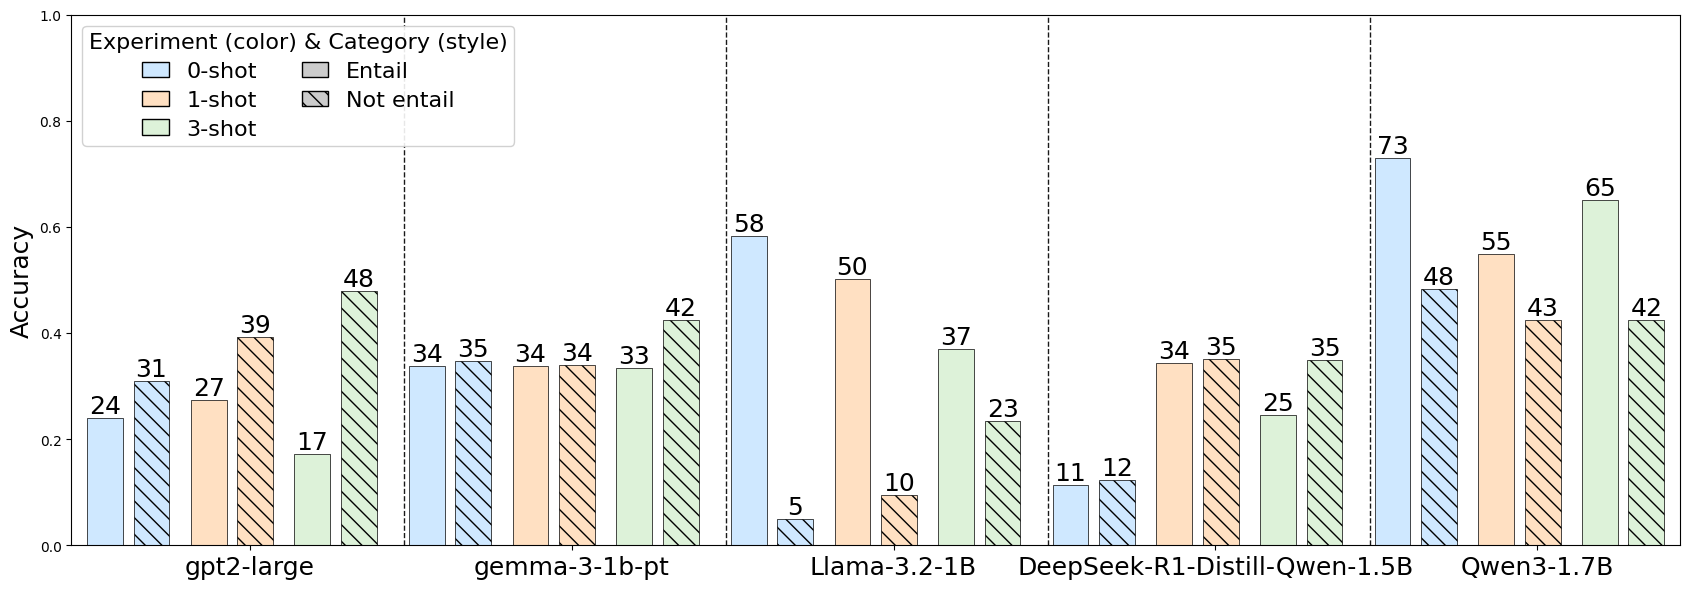

In [6]:
generate_multiway_plot(tram_stats, title="Model Performance for Temporal NLI in Entail and Not Entail Responses in General Domain", benchmark_name="Temporal NLI", labels=("entail", "not_entail"), savepath= "nli_bias_tram.svg",task_colors=task_colors, task_labels=task_labels)
